# Detekcija anomalija u financijskim transakcijama: algoritam izolacijskih stabala

Ova bilježnica implementira i evaluira algoritam izolacijskih stabala (engl. *Isolation Forest*) za detekciju prijevarnih transakcija, koristeći skup podataka Credit Card Fraud Detection (ULB, Kaggle).

Struktura prati poglavlje 4.4. završnog rada Izrada prototipa sustava za detekciju anomalija u financijskim sustavima u stvarnom vremenu primjenom metoda strojnog učenja.

Podatkovni skup dijeli se kronološki na tri dijela: skup za učenje (63 %), validacijski skup (7 %) i testni skup (30 %). Odabir hiperparametara i praga odlučivanja provodi se isključivo na validacijskom skupu; testni skup koristi se samo jednom, za konačnu evaluaciju.

In [1]:
#!pip install -q kagglehub scikit-learn pandas matplotlib seaborn
#!pip install - q joblib

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
import joblib

RANDOM_STATE = 42

## 1. Učitavanje podataka

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(f"{path}/creditcard.csv")
print(df.shape)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Eksplorativna analiza podataka (EDA)

In [4]:
print(df['Class'].value_counts())
print(f"Udio prijevara: {df['Class'].mean() * 100:.4f} %")

df['Amount'].describe()

Class
0    284315
1       492
Name: count, dtype: int64
Udio prijevara: 0.1727 %


,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


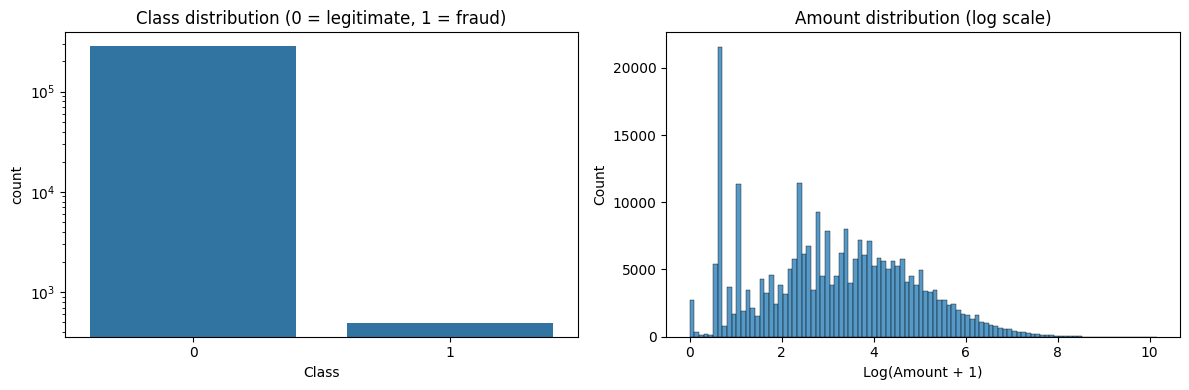

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Class', data=df, ax=axes[0])
axes[0].set_title('Class distribution (0 = legitimate, 1 = fraud)')
axes[0].set_yscale('log')

sns.histplot(np.log1p(df['Amount']), bins=100, ax=axes[1])
axes[1].set_title('Amount distribution (log scale)')
plt.xlabel('Log(Amount + 1)')
plt.tight_layout()
plt.show()

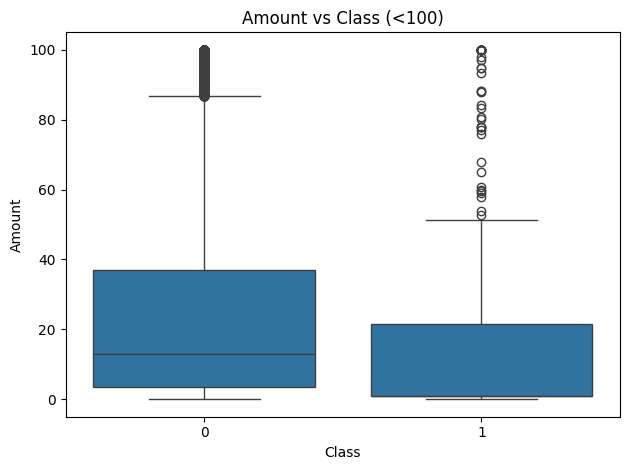

In [8]:
sns.boxplot(data=df[df['Amount']<100], x='Class', y='Amount')
plt.title('Amount vs Class (<100)')
plt.tight_layout()
plt.show()

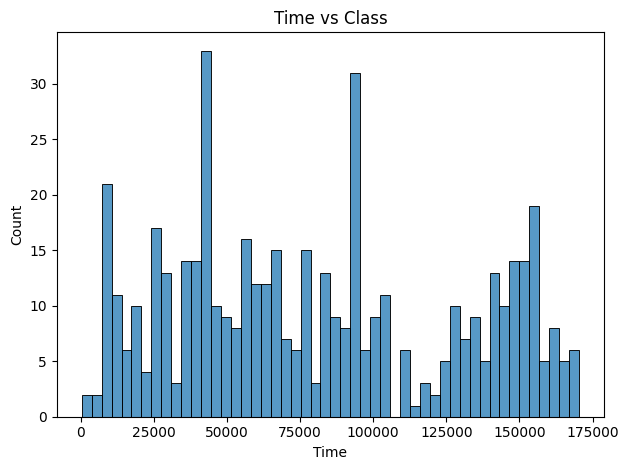

In [9]:
sns.histplot(data=df[df['Class'] == 1], x='Time', bins=50)
plt.title('Time vs Class')
plt.tight_layout()
plt.show()

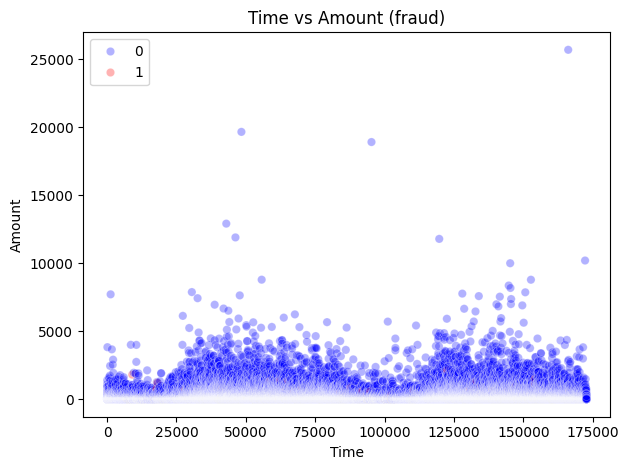

In [10]:
sns.scatterplot(data=df, x='Time', y='Amount', hue='Class', palette={0: 'blue', 1: 'red'}, alpha=0.3)
plt.title('Time vs Amount (fraud)')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Predobrada i podjela podataka

Značajke V1-V28 već su rezultat PCA transformacije originalnog skupa pa ih nije potrebno dodatno skalirati. Time i Amount skaliramo zasebno.

Prvo se podatci dijele kronološki na tri skupa, a tek zatim se
RobustScaler prilagođava (fit) isključivo na skupu za učenje; na validacijski i testni skup primjenjuje se već naučena transformacija (transform), bez ponovnog prilagođavanja. Time se u potpunosti sprječava curenje informacija iz validacijskog i testnog skupa u predobradu.

Omjer podjele: 63 % učenje, 7 % validacija, 30 % testiranje (validacijski skup izdvaja se iz prvotnih 70 % namijenjenih učenju).

In [11]:
n = len(df)
train_end = int(n * 0.63)
val_end = int(n * 0.70)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

amount_scaler = RobustScaler()
train_df['Amount_scaled'] = amount_scaler.fit_transform(train_df[['Amount']])
val_df['Amount_scaled'] = amount_scaler.transform(val_df[['Amount']])
test_df['Amount_scaled'] = amount_scaler.transform(test_df[['Amount']])

time_scaler = RobustScaler()
train_df['Time_scaled'] = time_scaler.fit_transform(train_df[['Time']])
val_df['Time_scaled'] = time_scaler.transform(val_df[['Time']])
test_df['Time_scaled'] = time_scaler.transform(test_df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
y_val = val_df['Class']
X_test = test_df[feature_cols]
y_test = test_df['Class']

print(f"Train: {X_train.shape}, Fraud rate: {train_df['Class'].mean() * 100:.4f} %")
print(f"Validation: {X_val.shape}, Fraud rate: {y_val.mean() * 100:.4f} %")
print(f"Test: {X_test.shape}, Fraud rate: {y_test.mean() * 100:.4f} %")

Train: (179428, 30), Fraud rate: 0.2029 %
Validation: (19936, 30), Fraud rate: 0.1003 %
Test: (85443, 30), Fraud rate: 0.1264 %


## 4. Početna konfiguracija

Model se trenira isključivo na skupu za učenje, bez korištenja oznaka klase. Parametar *contamination* postavljen je na 'auto' (ugrađena heuristika biblioteke scikit-learn), ne na udio prijevara procijenjen iz podataka. Time model ostaje u potpunosti nenadziran, bez ikakvog oslanjanja na poznate oznake tijekom treniranja ili konfiguracije.

In [12]:
iso_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso_forest.fit(X_train)

IsolationForest(n_estimators=200, n_jobs=-1, random_state=42)

## 5. Evaluacija početne konfiguracije na validacijskom skupu

Napomena: ovo je evaluacija na validacijskom skupu. Testni skup u ovom trenutku
još nije ni dotaknut.

Precision: 0.0137
Recall: 0.7000
F1-score: 0.0268
ROC-AUC: 0.9464
PR-AUC: 0.0145


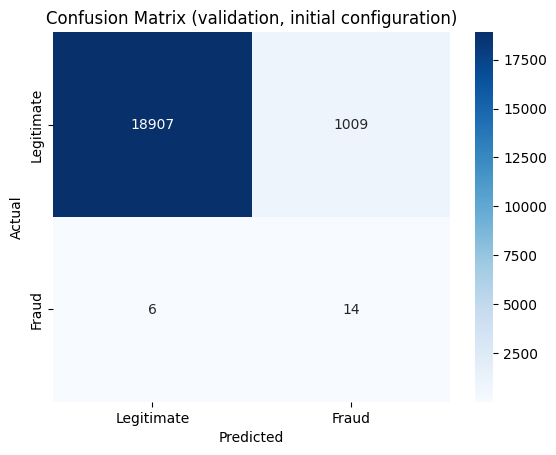

In [13]:
val_scores = -iso_forest.score_samples(X_val)
y_val_pred = (iso_forest.predict(X_val) == -1).astype(int)

precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, val_scores)
pr_auc = average_precision_score(y_val, val_scores)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix (validation, initial configuration)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

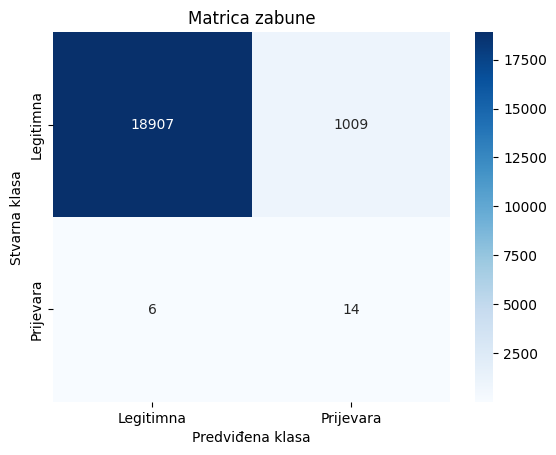

In [14]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimna', 'Prijevara'], yticklabels=['Legitimna', 'Prijevara'])
plt.title('Matrica zabune')
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()

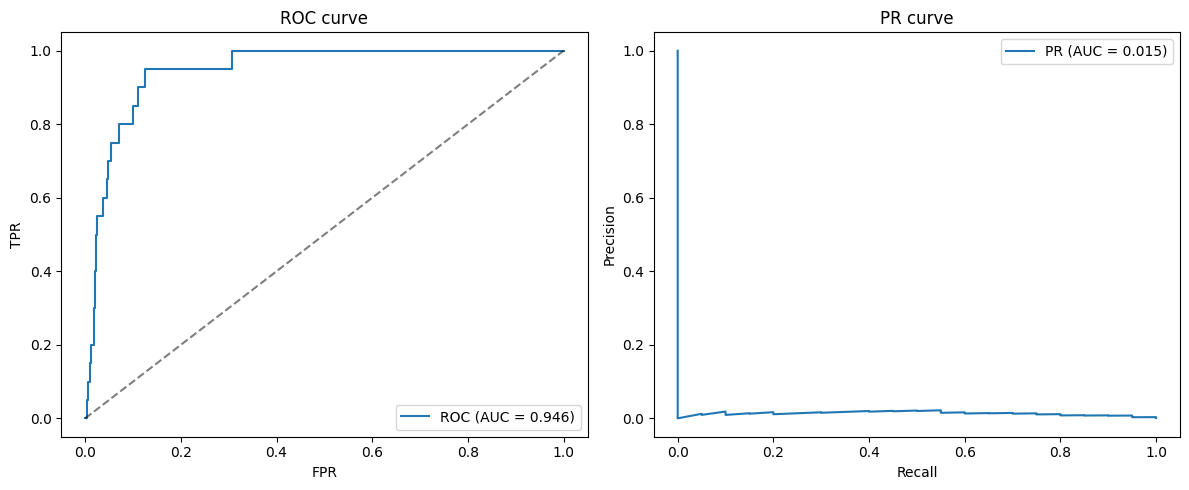

In [17]:
fpr, tpr, _ = roc_curve(y_val, val_scores)
prec_curve, rec_curve, _ = precision_recall_curve(y_val, val_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC curve')
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, label=f'PR (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR curve')
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Optimizacija praga odlučivanja (na validacijskom skupu)

Prag se određuje izravno iz krivulje preciznosti i odziva na validacijskom skupu, odabirom
vrijednosti koja maksimizira F1-mjeru.

In [16]:
prec_vals, rec_vals, thresholds_pr = precision_recall_curve(y_val, val_scores)

f1_vals = 2 * prec_vals * rec_vals / (prec_vals + rec_vals + 1e-12)
best_idx = np.argmax(f1_vals[:-1])
best_threshold = thresholds_pr[best_idx]

print(f"Optimal threshold (validation): {best_threshold:.4f}")
print(f"Precision: {prec_vals[best_idx]:.4f}")
print(f"Recall: {rec_vals[best_idx]:.4f}")
print(f"F1-score: {f1_vals[best_idx]:.4f}")

Optimal threshold (validation): 0.5377
Precision: 0.0219
Recall: 0.5500
F1-score: 0.0421


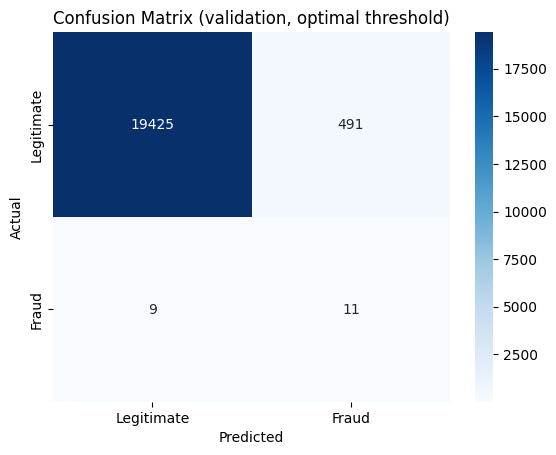

In [18]:
y_val_pred_optimal = (val_scores >= best_threshold).astype(int)

cm = confusion_matrix(y_val, y_val_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix (validation, optimal threshold)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

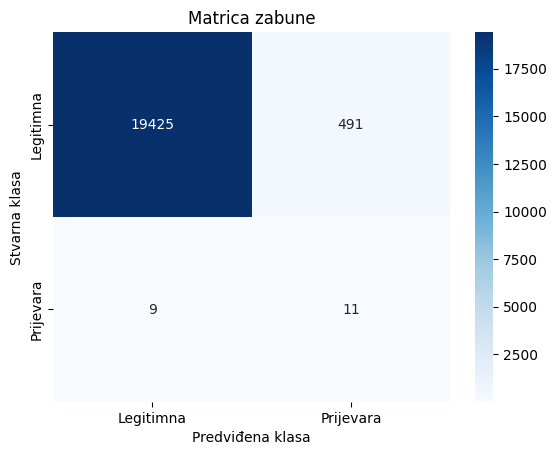

In [19]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimna', 'Prijevara'], yticklabels=['Legitimna', 'Prijevara'])
plt.title('Matrica zabune')
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()

## 7. Podešavanje hiperparametara (na validacijskom skupu)

Zadana vrijednost max_samples='auto' (256 uzoraka po stablu) ograničava količinu informacija dostupnih pojedinom stablu tijekom treniranja, neovisno o veličini skupa za učenje. Testira se veća vrijednost, max_samples=2048, i uspoređuje s baznom konfiguracijom (isključivo na validacijskom skupu).

In [27]:
iso_forest_v2 = IsolationForest(
    n_estimators=200,
    max_samples=2048,
    contamination='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest_v2.fit(X_train)

val_scores_v2 = -iso_forest_v2.score_samples(X_val)
roc_auc_v2 = roc_auc_score(y_val, val_scores_v2)
pr_auc_v2 = average_precision_score(y_val, val_scores_v2)

print(f"max_samples='auto' (initial model, validation): PR-AUC = {pr_auc:.4f}, ROC-AUC = {roc_auc:.4f}")
print(f"max_samples=2048 (new model, validation): PR-AUC = {pr_auc_v2:.4f}, ROC-AUC = {roc_auc_v2:.4f}")

max_samples='auto' (initial model, validation): PR-AUC = 0.0145, ROC-AUC = 0.9464
max_samples=2048 (new model, validation): PR-AUC = 0.0198, ROC-AUC = 0.9460


### 7.1. Optimizacija praga za poboljšani model (na validacijskom skupu)

Optimal threshold (max_samples=2048, validation): 0.4959
Precision: 0.0309
Recall: 0.6000
F1-score: 0.0588


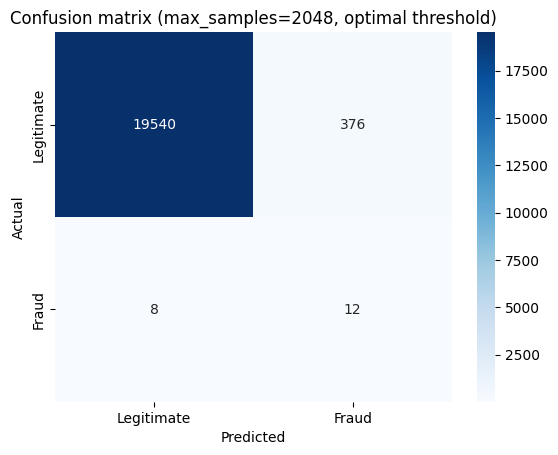

In [24]:
prec_vals_v2, rec_vals_v2, thresholds_pr_v2 = precision_recall_curve(y_val, val_scores_v2)

f1_vals_v2 = 2 * prec_vals_v2 * rec_vals_v2 / (prec_vals_v2 + rec_vals_v2 + 1e-12)
best_idx_v2 = np.argmax(f1_vals_v2[:-1])
best_threshold_v2 = thresholds_pr_v2[best_idx_v2]

print(f"Optimal threshold (max_samples=2048, validation): {best_threshold_v2:.4f}")
print(f"Precision: {prec_vals_v2[best_idx_v2]:.4f}")
print(f"Recall: {rec_vals_v2[best_idx_v2]:.4f}")
print(f"F1-score: {f1_vals_v2[best_idx_v2]:.4f}")

y_val_pred_v2_optimal = (val_scores_v2 >= best_threshold_v2).astype(int)

cm_v2_optimal = confusion_matrix(y_val, y_val_pred_v2_optimal)
sns.heatmap(cm_v2_optimal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion matrix (max_samples=2048, optimal threshold)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

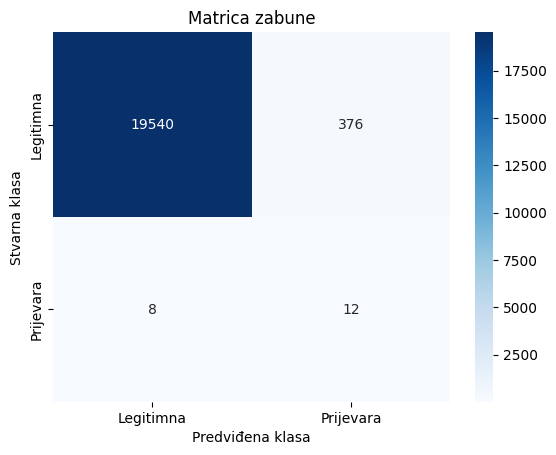

In [26]:
sns.heatmap(cm_v2_optimal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimna', 'Prijevara'], yticklabels=['Legitimna', 'Prijevara'])
plt.title('Matrica zabune')
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()

### 7.2. Kompromis preciznosti i odziva pri različitim pragovima (validacijski skup)

Isti prikaz kao ranije, ali za oba modela, na validacijskom skupu.

In [28]:
target_recalls = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

def tradeoff_table(rec_arr, prec_arr, thr_arr, f1_arr):
    rows = []
    for target in target_recalls:
        valid_idx = np.where(rec_arr[:-1] >= target)[0]
        if len(valid_idx) == 0:
            continue
        idx = valid_idx[-1]
        rows.append({
            'Target recall': target,
            'Threshold': round(thr_arr[idx], 4),
            'Precision': round(prec_arr[idx], 4),
            'Recall': round(rec_arr[idx], 4),
            'F1-score': round(f1_arr[idx], 4)
        })
    return pd.DataFrame(rows)

print("Initial configuration (max_samples='auto'):")
display(tradeoff_table(rec_vals, prec_vals, thresholds_pr, f1_vals))

print("Improved configuration (max_samples=2048):")
display(tradeoff_table(rec_vals_v2, prec_vals_v2, thresholds_pr_v2, f1_vals_v2))

Initial configuration (max_samples='auto'):


,Target recall,Threshold,Precision,Recall,F1-score
0,0.2,0.5840,0.0167,0.2,0.0309
1,0.3,0.5610,0.0164,0.3,0.0312
2,0.4,0.5537,0.0199,0.4,0.0379
3,0.5,0.5420,0.0212,0.5,0.0407
4,0.6,0.5165,0.0163,0.6,0.0318
5,0.7,0.5039,0.0147,0.7,0.0288


Improved configuration (max_samples=2048):


,Target recall,Threshold,Precision,Recall,F1-score
0,0.2,0.5515,0.0212,0.2,0.0383
1,0.3,0.5184,0.0217,0.3,0.0405
2,0.4,0.5148,0.0278,0.4,0.0519
3,0.5,0.4970,0.0262,0.5,0.0498
4,0.6,0.4959,0.0309,0.6,0.0588
5,0.7,0.4678,0.0257,0.7,0.0496


## 8. Konačna evaluacija na testnom skupu

Ovo je prvi i jedini put da se testni skup koristi u ovoj bilježnici. Koristi se konačna konfiguracija (max_samples=2048) i prag odabran na validacijskom skupu (best_threshold_v2).

Final results (test):
Precision: 0.0489
Recall: 0.6481
F1-score: 0.0910
ROC-AUC: 0.9426
PR-AUC: 0.0486


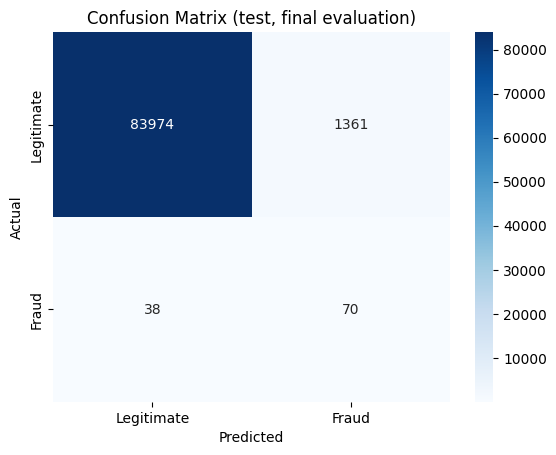

In [29]:
test_scores = -iso_forest_v2.score_samples(X_test)
y_test_pred = (test_scores >= best_threshold_v2).astype(int)

precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, test_scores)
pr_auc_test = average_precision_score(y_test, test_scores)

print("Final results (test):")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1-score: {f1_test:.4f}")
print(f"ROC-AUC: {roc_auc_test:.4f}")
print(f"PR-AUC: {pr_auc_test:.4f}")

cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix (test, final evaluation)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

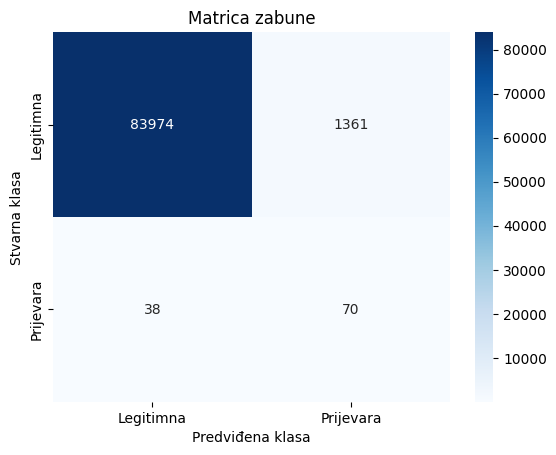

In [30]:
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimna', 'Prijevara'], yticklabels=['Legitimna', 'Prijevara'])
plt.title('Matrica zabune')
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()

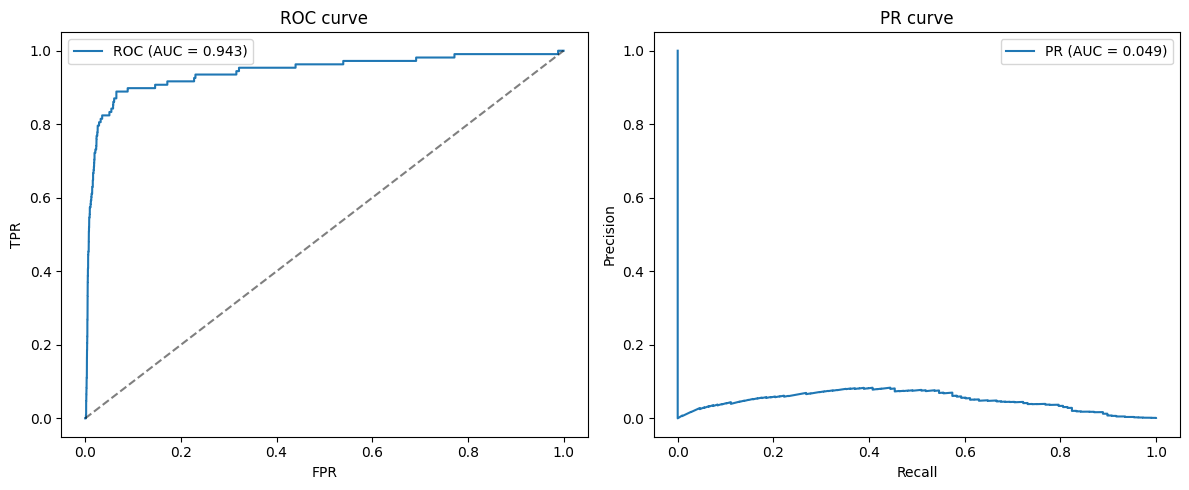

In [31]:
fpr, tpr, _ = roc_curve(y_test, test_scores)
prec_test_curve, rec_test_curve, _ = precision_recall_curve(y_test, test_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_test:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC curve')
axes[0].legend()

axes[1].plot(rec_test_curve, prec_test_curve, label=f'PR (AUC = {pr_auc_test:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR curve')
axes[1].legend()
plt.tight_layout()
plt.show()

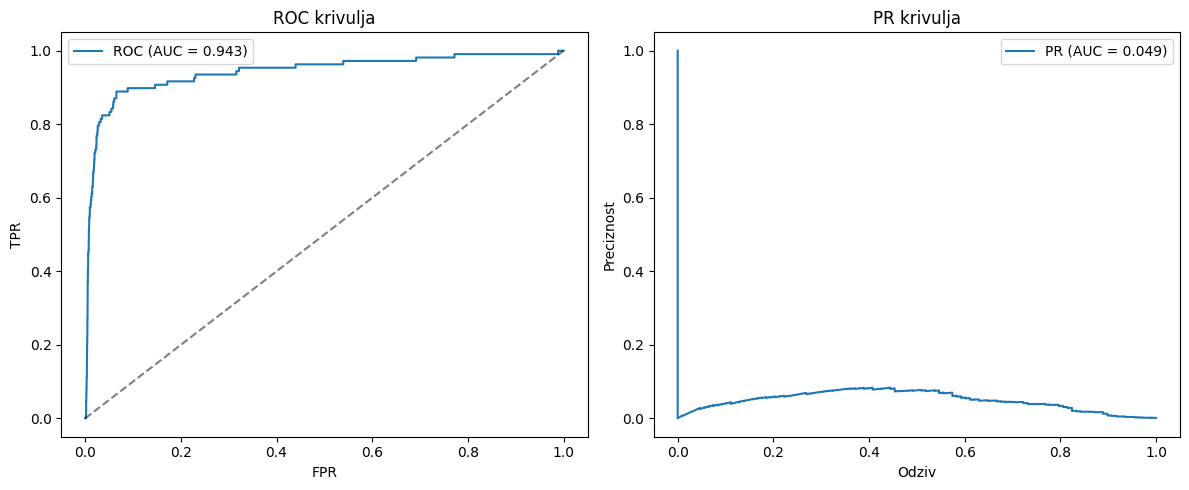

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_test:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC krivulja')
axes[0].legend()

axes[1].plot(rec_test_curve, prec_test_curve, label=f'PR (AUC = {pr_auc_test:.3f})')
axes[1].set_xlabel('Odziv')
axes[1].set_ylabel('Preciznost')
axes[1].set_title('PR krivulja')
axes[1].legend()
plt.tight_layout()
plt.show()

## 9. Vizualizacija distribucije klasa i granice odlučivanja (2D projekcija)

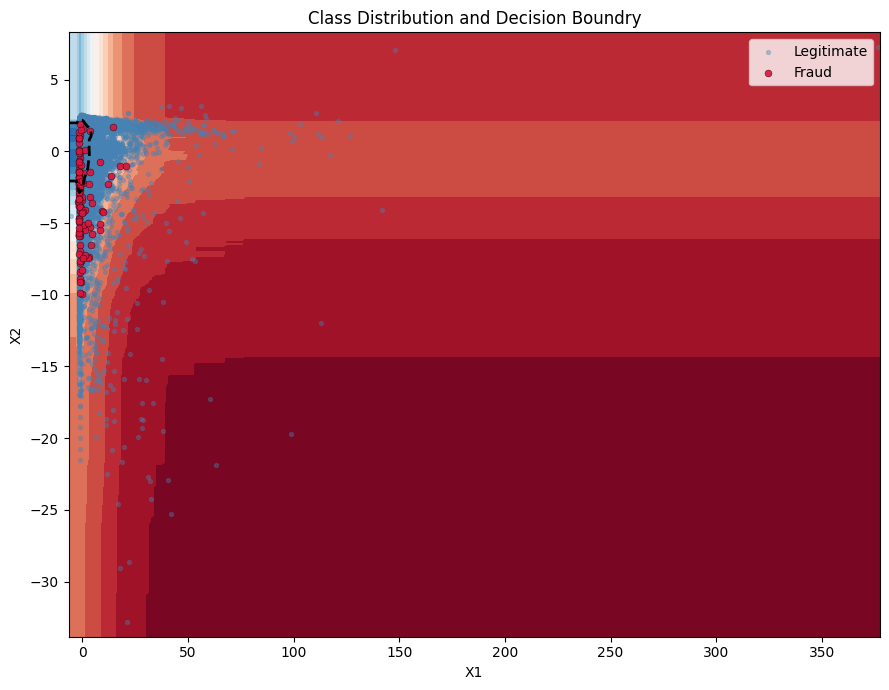

In [34]:
visual_pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = visual_pca.fit_transform(X_train)
X_test_2d = visual_pca.transform(X_test)

iso_forest_2d = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=RANDOM_STATE
)
iso_forest_2d.fit(X_train_2d)

x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = iso_forest_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu')
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black', linestyles='dashed')

y_test_arr = y_test.values
plt.scatter(X_test_2d[y_test_arr == 0, 0], X_test_2d[y_test_arr == 0, 1],
            c='steelblue', s=8, alpha=0.35, label='Legitimate')
plt.scatter(X_test_2d[y_test_arr == 1, 0], X_test_2d[y_test_arr == 1, 1],
            c='crimson', s=25, alpha=0.9, label='Fraud', edgecolors='k', linewidths=0.3)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Class Distribution and Decision Boundry')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Spremanje modela

In [35]:
joblib.dump(iso_forest_v2, 'isolation_forest_model.pkl')
joblib.dump(amount_scaler, 'amount_scaler_if.pkl')
joblib.dump(time_scaler, 'time_scaler_if.pkl')
print(f"Final model (max_samples=2048), threshold ({best_threshold_v2:.4f}) i scalers saved.")

Final model (max_samples=2048), threshold (0.4959) i scalers saved.
